<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II </b></h1>

<h3><b> Exploratory Data Analysis and Pre-Processing </b></h3>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1 Imports and Data Loading </b></h3>

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
In this section, we import the necessary libraries for data manipulation, visualization, and preprocessing. 

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
import contextily as ctx
import folium
from folium.plugins import MarkerCluster
import warnings

import utils_eda as utils
warnings.filterwarnings("ignore")


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.1 Data Analysis </b></h3>

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
After loading the data, we perform a deep dive into the dataset's structure to ensure its integrity before moving to the feature engineering and modeling phases.

In [2]:
path = "/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/datasets/customer_info.csv"
ci = pd.read_csv(path, index_col='customer_id')

In [3]:
pd.set_option('display.max_columns', None)
ci.sort_index(inplace = True)
display(ci.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


In [4]:
display(ci.tail())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
39996,Joshua Howard,male,05/16/1973 02:04 PM,0.0,0.0,2.0,1.0,475.0,13488.0,NaN,190.0,573.0,994.0,1020.0,1154.0,62.0,1598.0,366.0,162.0,0.261352,2014.0,NaN,38.742306,-9.163971
39997,Anthony Hines,male,05/10/1955 01:19 AM,1.0,0.0,1.0,1.0,8430.0,14408.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,2105.0,227.0,97.0,0.143479,2014.0,NaN,38.748505,-9.193445
39998,Edna Hasselman,female,05/15/1945 11:09 PM,1.0,1.0,0.0,4.0,8029.0,1480.0,14.0,1600.0,494.0,117.0,307.0,NaN,1719.0,89.0,258.0,206.0,0.181917,2012.0,NaN,38.776003,-9.137943
39999,George Kramer,male,05/25/1951 09:02 PM,1.0,1.0,1.0,6.0,8364.0,3114.0,11.0,596.0,303.0,661.0,NaN,113.0,410.0,NaN,225.0,385.0,0.807259,2017.0,NaN,38.736034,-9.145235
40000,Sammie Wright,female,07/09/1990 10:27 AM,0.0,1.0,1.0,1.0,4774.0,2127.0,7.0,701.0,387.0,126.0,816.0,729.0,1331.0,323.0,239.0,102.0,0.252563,2017.0,NaN,38.758936,-9.145988


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
We use the `.info()` method to verify the column names, non-null counts, and data types. This allows us to identify columns that require type conversion (e.g., dates or numerical counts stored as floats) and gives us an initial glimpse of the data density.

In [5]:
display(ci.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   customer_gender                          33038 non-null  object 
 2   customer_birthdate                       32873 non-null  object 
 3   kids_home                                32708 non-null  float64
 4   teens_home                               32708 non-null  float64
 5   number_complaints                        32377 non-null  float64
 6   distinct_stores_visited                  32708 non-null  float64
 7   lifetime_spend_groceries                 33038 non-null  float64
 8   lifetime_spend_electronics               32377 non-null  float64
 9   typical_hour                             32377 non-null  float64
 10  lifetime_spend_vegetables                32377 non-

None

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.2 Duplicate Rows Analysis </b></h3>

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
To ensure the reliability of our clusters, we check for duplicate records. Duplicate rows can artificially inflate the importance of certain customer profiles and lead to biased segmentation results.

In [6]:
duplicate_rows = ci[ci.duplicated()]
display(duplicate_rows.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,


<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
While checking for exact row duplicates is standard, it is also important to perform a more granular search for "logical duplicates". 

In this step, we specifically look for records that share the same **Customer Name** and **Birthdate**. Identifying such cases is vital because:
* **Data Overlap:** The same individual might have been registered twice under different IDs.
* **Clustering Bias:** If the same customer profile appears multiple times, it will unfairly pull a cluster center toward its specific attributes, distorting the final segmentation.

In [7]:
ci[ci[['customer_name', 'customer_birthdate']].duplicated()]

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.3 Missing Values Analysis </b></h3>

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">
    
Missing data is a common challenge in customer datasets. We generate a missing value report to:
* Quantify the percentage of missing information per feature.
* Visualize the missind data using a barplot.
* Determine which variables require **KNN Imputation** and which ones might be too empty to be useful.

In [8]:
missing_df = utils.get_missing_percent(ci)

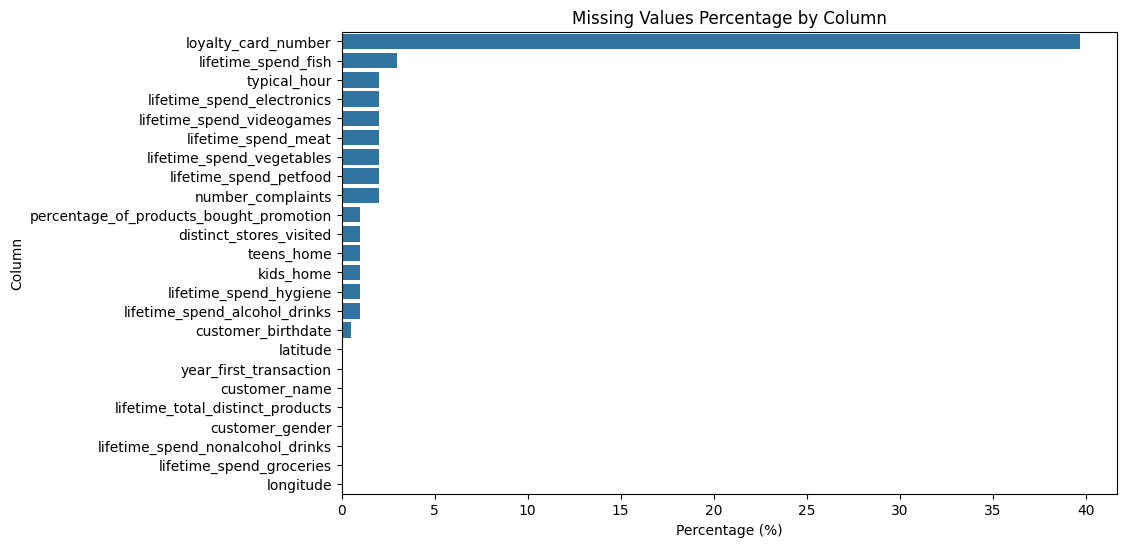

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x='Missing_Percent', y='Column', data=missing_df)
plt.title("Missing Values Percentage by Column")
plt.xlabel("Percentage (%)")
plt.ylabel("Column")
plt.show()

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

We identify features with a missing value percentage higher than **30%**. This threshold is critical because:
* **Information Loss:** Variables with high sparsity often lack enough signal to be reliably imputed.
* **Model Integrity:** Including features with excessive missing data can introduce significant noise into the clustering process, potentially leading to distorted segments.


In [10]:
high_missing = missing_df[missing_df['Missing_Percent'] > 30]
display(high_missing)

,Column,Missing_Percent
21,loyalty_card_number,39.67


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
We evaluate the number of unique values in the `loyalty_card_number` column to determine its nature.

In [11]:
print(f"Unique Values of column loyalty_card_number: {ci['loyalty_card_number'].nunique()}")

Unique Values of column loyalty_card_number: 1


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.4 Define Numerical and Categorical Columns</b></h3>

In [12]:
numerical_cols = ci.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = ci.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
display(pd.DataFrame(numerical_cols, columns=['Numerical Columns']))

print(f"Categorical columns ({len(categorical_cols)}):")
display(pd.DataFrame(categorical_cols, columns=['Categorical Columns']))

Numerical columns (21):


,Numerical Columns
0,kids_home
1,teens_home
2,number_complaints
3,distinct_stores_visited
4,lifetime_spend_groceries
5,lifetime_spend_electronics
6,typical_hour
7,lifetime_spend_vegetables
8,lifetime_spend_nonalcohol_drinks
9,lifetime_spend_alcohol_drinks


Categorical columns (3):


,Categorical Columns
0,customer_name
1,customer_gender
2,customer_birthdate


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px; ">

To properly prepare our preprocessing pipeline, we categorize the variables into Numerical and Categorical types. This distinction is essential as each group requires specific cleaning and transformation strategies.

Numerical Features (21 Variables)
These columns represent quantitative data, including spending amounts, household counts, and geographic coordinates.
* **Household & Behavior:** `kids_home`, `teens_home`, `number_complaints`, `distinct_stores_visited`.
* **Spending Habits:** `lifetime_spend_` (Groceries, Electronics, Vegetables, Non-alcoholic, Alcohol, Meat, Fish, Hygiene, Videogames, Petfood).
* **Metrics & Time:** `lifetime_total_distinct_products`, `percentage_of_products_bought_promotion`, `typical_hour`, `year_first_transaction`.
* **Geospatial & IDs:** `latitude`, `longitude`, `loyalty_card_number`.

Categorical Features (3 Variables)
These columns contain qualitative information or timestamps that define the customer profile.
* **Demographics:** `customer_gender`.
* **Identification:** `customer_name`.
* **Temporal:** `customer_birthdate` (to be used for age calculation).

</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.4.1 Finds in Categorical Columns</b></h3>

In [13]:
ci[["customer_name"]]

,customer_name
customer_id,
3,Bsc. Crystal Kitchens
4,Bsc. Glenda Bauman
5,Msc. Antonio Campbell
7,John Kelling
8,Arthur Dematteo
...,...
39996,Joshua Howard
39997,Anthony Hines
39998,Edna Hasselman


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

A detailed inspection of the `customer_name` field reveals that it contains more than just identification data. Many entries include academic prefixes such as **Bsc.**, **Msc.**, and **Phd.**

* **Observation:** The dataset contains 33,038 unique customer names.
* **Feature Engineering Opportunity:** These prefixes are a proxy for the customer's **Education Level**. Instead of treating names as simple strings, we can extract these titles to create an ordinal numerical feature (e.g., 1 for Bsc, 2 for Msc, 3 for Phd).
* **Data Cleaning:** Once the education level is extracted, the names can be cleaned of these prefixes to standardize the field, although the names themselves will eventually be excluded from the clustering model to protect privacy and focus on behavioral patterns.

</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 1.5 Statistical Summary</b></h3>

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">
    
We perform a statistical summary of the numerical features using the `.describe()` method. This allows us to observe the central tendency, dispersion, and range of our variables, providing critical insights into the data's distribution.


In [14]:
print("Statistical summary for numerical columns:")
ci[numerical_cols].describe().T

Statistical summary for numerical columns:


,count,mean,std,min,25%,50%,75%,max
kids_home,32708.0,1.116118,1.150186,0.000000,0.000000,1.000000,1.000000,8.000000
teens_home,32708.0,0.898893,0.962924,0.000000,0.000000,1.000000,1.000000,6.000000
number_complaints,32377.0,0.930846,0.894658,0.000000,0.000000,1.000000,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,13002.500000,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1470.000000,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,12.000000,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,471.000000,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,421.000000,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,483.000000,891.250000,3704.000000


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

Based on the summary table, we can identify several areas that require attention during the pre-processing phase:

* **Constant Features:** The `loyalty_card_number` has a standard deviation of **0.0**, confirming it is a constant value across the dataset and provides no predictive power for clustering.
* **Data Entry Errors:** **Negative Values:** The `percentage_of_products_bought_promotion` shows a minimum value of **-1.27**, which is physically impossible for a percentage.
    * **Future Dates:** The `year_first_transaction` has a maximum value of **2029**, indicating erroneous entries that exceed the current year.
* **Spending Variance:** Columns like `lifetime_spend_groceries` and `lifetime_spend_electronics` exhibit very high standard deviations relative to their means. This suggests a high degree of heterogeneity in customer behavior, which is ideal for segmentation but also indicates the presence of **extreme outliers** that must be capped.
* **Missing Data Clues:** The varying "count" values (ranging from ~20k to 33k) confirm that several features have significant gaps that will be addressed via **KNN Imputation**.

</div>

In [15]:
condition = (ci['percentage_of_products_bought_promotion'] < 0.0) | (ci['percentage_of_products_bought_promotion'] > 1.0)
rows_wrong = ci[condition]
display(rows_wrong.head())

,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
12,Phd. Dorothy Pacheco,female,05/19/2000 03:02 AM,0.0,0.0,0.0,2.0,9281.0,254.0,18.0,125.0,60.0,1549.0,139.0,598.0,673.0,71.0,64.0,29.0,-0.131176,2018.0,NaN,38.748616,-9.167756
35,Bsc. Thomas King,male,08/08/1979 05:25 AM,NaN,1.0,0.0,2.0,37795.0,2130.0,8.0,636.0,102.0,310.0,890.0,844.0,842.0,42.0,524.0,212.0,-0.025524,2011.0,1.0,38.762036,-9.158847
37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
81,Phd. Denise Allard,female,03/18/1992 06:34 PM,2.0,0.0,2.0,1.0,6273.0,430.0,6.0,208.0,291.0,525.0,539.0,804.0,707.0,121.0,320.0,91.0,-0.217805,2020.0,1.0,38.748092,-9.155615
87,Phd. Milagro Amelung,female,09/03/1977 11:26 AM,1.0,1.0,1.0,3.0,28825.0,2948.0,15.0,459.0,687.0,716.0,884.0,1495.0,1314.0,161.0,916.0,337.0,-0.022180,2008.0,1.0,38.776791,-9.146792


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

We perform a targeted integrity check on the `percentage_of_products_bought_promotion` feature. Since this variable represents a ratio, any value outside the range of **[0, 1]** is considered a data entry error.

* **Condition defined:** We filter for values strictly less than 0.0 or greater than 1.0.
* **Findings:** As noted in the descriptive statistics, there are records with negative values (e.g., -1.27), which are physically impossible.
* **Objective:** Identifying these specific rows allows us to treat them as "missing data" (NaN), ensuring they are later corrected by our **KNN Imputation** strategy rather than biasing our analysis with impossible values.

</div>

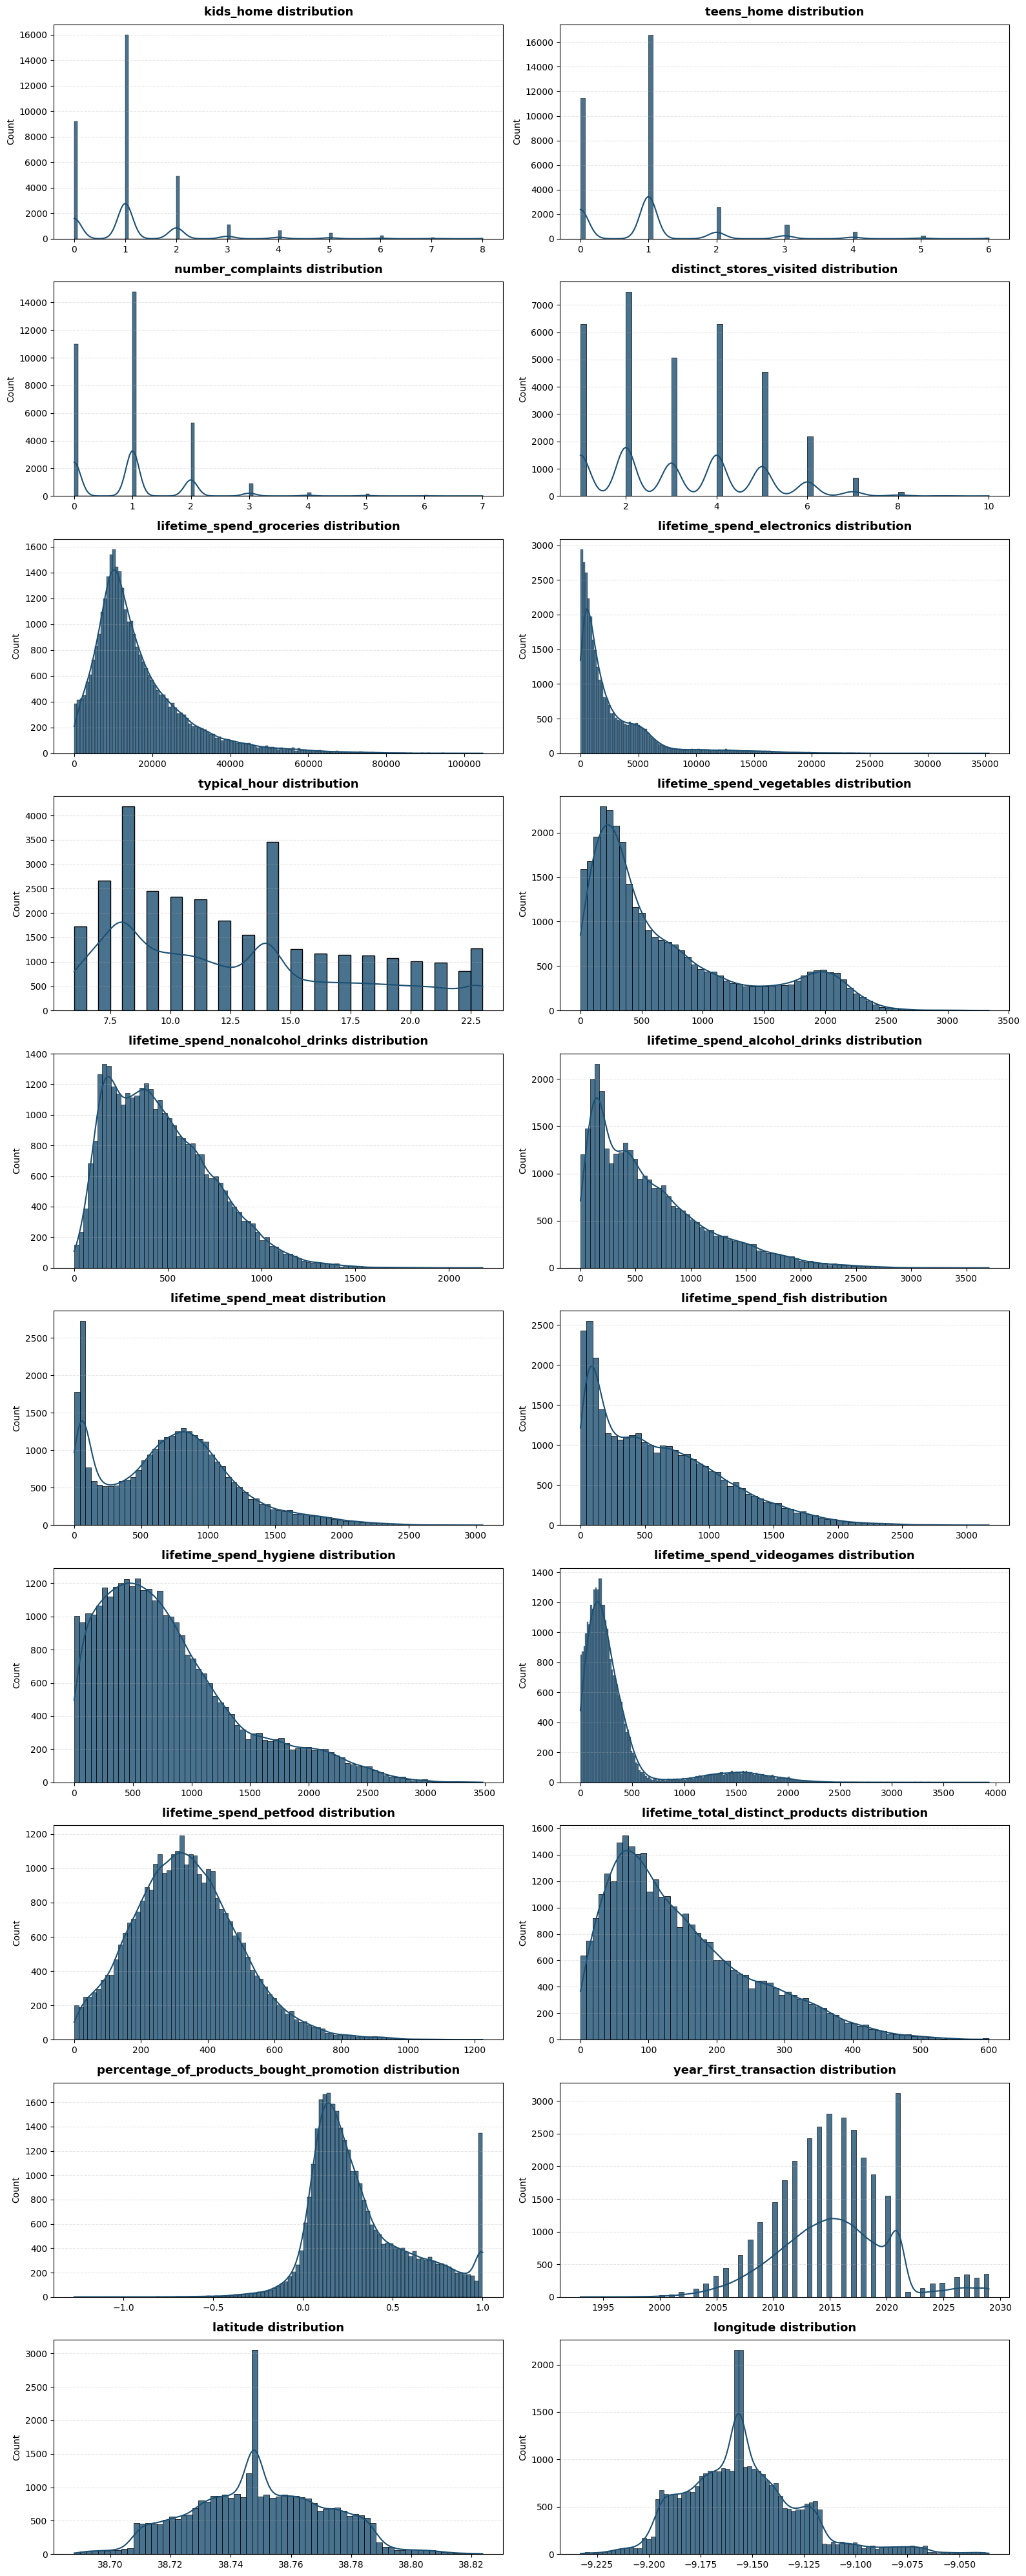

In [16]:
CUSTOM_BLUE = "#1B4F72"

vars_to_plot = list(ci.select_dtypes(include=np.number).columns)
for col in ['loyalty_card_number', 'customer_id', 'customer_loyalty_flag']:
    if col in vars_to_plot: vars_to_plot.remove(col)

fig, axes = plt.subplots(nrows=(len(vars_to_plot) + 1) // 2, ncols=2, figsize=(16, len(vars_to_plot) * 2))
axes = axes.flatten()

for i, col in enumerate(vars_to_plot):
    sns.histplot(ci[col], kde=True, ax=axes[i], color=CUSTOM_BLUE, alpha=0.8)
    axes[i].set_title(f'{col} distribution', fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

The histograms allow us to understand the "shape" of our customer base.

#### **Spending Categories**
* **Skewness:** Most spending features (Electronics, Alcohol, Meat) are **right-skewed**. A large portion of customers spends small amounts, while a "long tail" of high-spenders exists.
* **Outliers:** The boxplots confirm significant outliers in `lifetime_spend_electronics` and `lifetime_spend_groceries`. This reinforces the need for the **IQR Capping** strategy we implemented to prevent these extreme cases from dominating the cluster definitions.

#### **Temporal & Behavioral Patterns**
* **Typical Hour:** The distribution shows peaks during specific times of the day. We wil use the **Sine/Cosine transformation**to preserve the proximity between the late-night and early-morning peaks.
* **Promotion Sensitivity:** The distribution of `percentage_of_products_bought_promotion` shows that while most customers are moderately sensitive to deals, there is a distinct group of "deal hunters" who buy almost exclusively on promotion.

</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.DATA CLEANING</b></h3>

In [17]:
ci_clean = ci.copy()

print("Initial shape:", ci_clean.shape)

Initial shape: (33038, 24)


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.1 Detecting Invalid Future Years in Dataset</b></h3>

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

To convert static dates into dynamic behavioral features, we first establish the current temporal baseline.

* **Objective:** Capture the current year using `pd.Timestamp.now().year`.
* **Application:** This value serves as the reference point for calculating:
    * **Customer Age:** Derived from `customer_birthdate`.
    * **Customer Tenure:** Calculated as the difference between the current year and the `year_first_transaction`.
* **Impact:** Transforming years and dates into "Age" and "Years as Customer" provides the clustering algorithm with numerical distances that represent lifecycle stages, which is far more predictive than raw date strings.

</div>

In [18]:
current_year = pd.Timestamp.now().year
print("Current year:", current_year)

Current year: 2026


In [19]:
# Check invalid values BEFORE fixing
invalid_years = ci_clean[ci_clean['year_first_transaction'] > current_year]
print("\nInvalid future years found:")
display(invalid_years['year_first_transaction'].unique())


Invalid future years found:


array([2029., 2028., 2027.])

In [20]:
invalid_years_rows = utils.get_invalid_years(ci_clean)

if not invalid_years_rows.empty:
    print(f"Future years detected: {invalid_years_rows['year_first_transaction'].unique()}")
    display(invalid_years_rows.head())

Future years detected: [2029. 2028. 2027.]


,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
customer_id,,,,,,,,,,,,,,,,,,,,,,,,
25,Phd. Tom Fisher,male,03/17/2001 10:08 AM,0.0,0.0,NaN,2.0,8829.0,345.0,8.0,NaN,121.0,1657.0,1028.0,758.0,91.0,475.0,44.0,61.0,0.653237,2029.0,1.0,38.707590,-9.161818
37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
82,Msc. Heather Howie,female,09/25/2001 01:21 AM,0.0,0.0,0.0,2.0,8073.0,1372.0,8.0,123.0,304.0,1326.0,367.0,259.0,237.0,441.0,171.0,49.0,0.609053,2029.0,1.0,38.756427,-9.162594
115,Toni Sultan,female,03/14/1999 10:40 PM,1.0,1.0,2.0,1.0,17941.0,16101.0,23.0,268.0,596.0,1422.0,700.0,839.0,197.0,1409.0,294.0,161.0,0.414479,2027.0,1.0,38.722565,-9.149736
141,Bsc. Evelyn Hoffman,female,01/13/2000 07:00 AM,0.0,0.0,0.0,2.0,11257.0,412.0,9.0,1636.0,485.0,103.0,99.0,85.0,1846.0,115.0,14.0,191.0,0.304802,2028.0,1.0,38.754510,-9.183423


In [21]:
# Apply correction
ci_clean['year_first_transaction'] = ci_clean['year_first_transaction'].clip(upper=current_year)

In [22]:
# Validate AFTER fixing
print("\nMax year after correction:", ci_clean['year_first_transaction'].max())


Max year after correction: 2026.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.2 Detecting Features with Negative Values</b></h3>

In [23]:
negative_values = ci_clean.select_dtypes(include=['number']).lt(0).any()
negative_values

kids_home                                  False
teens_home                                 False
number_complaints                          False
distinct_stores_visited                    False
lifetime_spend_groceries                   False
lifetime_spend_electronics                 False
typical_hour                               False
lifetime_spend_vegetables                  False
lifetime_spend_nonalcohol_drinks           False
lifetime_spend_alcohol_drinks              False
lifetime_spend_meat                        False
lifetime_spend_fish                        False
lifetime_spend_hygiene                     False
lifetime_spend_videogames                  False
lifetime_spend_petfood                     False
lifetime_total_distinct_products           False
percentage_of_products_bought_promotion     True
year_first_transaction                     False
loyalty_card_number                        False
latitude                                   False
longitude           

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

### Negative Value Analysis

To ensure the logical consistency of our features before modeling, we scan all numerical columns for values below zero.

* **Objective:** Use `.lt(0).any()` to detect logical anomalies across numerical datatypes.
* **Findings:**
    * **`longitude`:** Contains negative values, which is **logically valid** (representing the Western Hemisphere).
    * **`percentage_of_products_bought_promotion`:** Contains negative values, which is a **logical error** for a percentage metric.
* **Impact:** Identifying these anomalies prevents the inclusion of "placeholder" values (like -1 for missing data) that would otherwise distort the mean and variance of features during the clustering process.

</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>2.3 Fix Negative Percentages</b></h3>

In [24]:
negative_values = ci_clean[ci_clean['percentage_of_products_bought_promotion'] < 0]
print("Negative values found:")
display(negative_values['percentage_of_products_bought_promotion'].head())

Negative values found:


customer_id
12   -0.131176
35   -0.025524
37   -0.184820
81   -0.217805
87   -0.022180
Name: percentage_of_products_bought_promotion, dtype: float64

In [25]:
ci_clean['percentage_of_products_bought_promotion'] = ci_clean[
    'percentage_of_products_bought_promotion'
].clip(lower=0)

In [26]:
print("\nMinimum value after correction:")
print(ci_clean['percentage_of_products_bought_promotion'].min())


Minimum value after correction:
0.0


In [27]:
print("Maximum value:")
print(ci_clean['percentage_of_products_bought_promotion'].max())

Maximum value:
1.0


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

### Data Correction: Percentage Boundary Clipping

Upon discovering illogical negative values in the promotion frequency data, we implement a clipping transformation to normalize the feature.

* **Objective:** Remove negative noise from `percentage_of_products_bought_promotion` using the `.clip(lower=0)` method.
* **Logic:** Values below **0.0** are raised to the floor of **0.0**.
    * This preserves the integrity of the remaining distribution while ensuring all values fall within the mathematically valid range $[0, 1]$.
* **Validation:** Post-correction checks confirm a new **Minimum Value of 0.0** and a **Maximum Value of 1.0**, successfully aligning the feature with expected probability boundaries.

</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.4 Fix Columns Data Types</b></h3>

In [28]:
ci_clean['customer_birthdate'] = pd.to_datetime(ci_clean['customer_birthdate'], format = '%m/%d/%Y %I:%M %p')

In [29]:
int_columns = [
    'kids_home', 'teens_home', 'number_complaints',
    'distinct_stores_visited', 'typical_hour',
    'lifetime_total_distinct_products', 'year_first_transaction'
]

for col in int_columns:
    if col in ci_clean.columns:
        ci_clean[col] = pd.to_numeric(ci_clean[col], errors='coerce')

In [30]:
ci_clean['loyalty_card_number']

customer_id
3        1.0
4        1.0
5        NaN
7        1.0
8        1.0
        ... 
39996    NaN
39997    NaN
39998    NaN
39999    NaN
40000    NaN
Name: loyalty_card_number, Length: 33038, dtype: float64

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

To ensure mathematical operations and time-series analyses function correctly, we cast raw object columns into their appropriate structural formats.

* **Objective:** Convert string-based dates and mixed-type numerical strings into usable `datetime64` and `numeric` formats.
* **Key Transformations:**
    * **Temporal Casting:** `customer_birthdate` is parsed using a specific format string (`%m/%d/%Y %I:%M %p`) to enable age calculations.
    * **Integer Enforcement:** Columns like `kids_home` and `number_complaints` are coerced to numeric types. By using `errors='coerce'`, any non-numeric noise is safely converted to `NaN`.
* **Impact:** Standardizing types is critical for the "Temporal Baseline" established earlier. For instance, `loyalty_card_number` is revealed as a Boolean-style float (1.0 or NaN), which can now be treated as a categorical flag for loyalty membership.

</div>

In [31]:
ci_clean['typical_hour'] = pd.to_numeric(ci_clean['typical_hour'], errors='coerce')

ci_clean = utils.apply_cyclic_transformation(ci_clean, 'typical_hour', max_val=24)

print(ci_clean[['typical_hour', 'typical_hour_sin', 'typical_hour_cos']].head())

             typical_hour  typical_hour_sin  typical_hour_cos
customer_id                                                  
3                     NaN               NaN               NaN
4                     NaN               NaN               NaN
5                    11.0          0.258819     -9.659258e-01
7                    18.0         -1.000000     -1.836970e-16
8                    17.0         -0.965926     -2.588190e-01


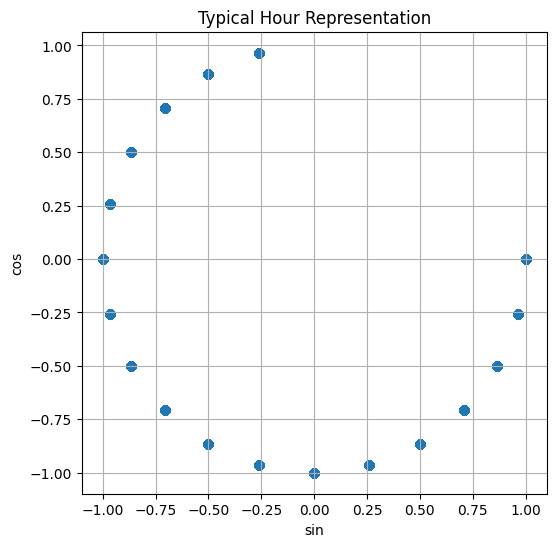

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(ci_clean['typical_hour_sin'], ci_clean['typical_hour_cos'])
plt.title('Typical Hour Representation')
plt.xlabel('sin')
plt.ylabel('cos')
plt.grid(True)
plt.show()

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


Time-of-day data is inherently cyclical (23:00 is closer to 01:00 than it is to 13:00). To ensure our model understands this relationship, we map the linear `typical_hour` onto a 2D coordinate system.

* **Objective:** Transform the 24-hour cycle into Sine and Cosine components using a `cyclic_transformation`.
* **The Logic:** Raw numerical hours (0-23) create a "jump" or distance gap between the end of one day and the start of the next.
    * By mapping hours to a circle, **Hour 23** and **Hour 0** become spatially adjacent, preserving the temporal continuity of human behavior.
* **Impact:** The resulting scatter plot forms a perfect circle, confirming that the "Typical Hour" has been successfully projected into a format that allows clustering algorithms to calculate meaningful distances between different times of day.

</div>

In [33]:
print("Updated data types:")
display(ci_clean.dtypes)

Updated data types:


customer_name                                      object
customer_gender                                    object
customer_birthdate                         datetime64[ns]
kids_home                                         float64
teens_home                                        float64
number_complaints                                 float64
distinct_stores_visited                           float64
lifetime_spend_groceries                          float64
lifetime_spend_electronics                        float64
typical_hour                                      float64
lifetime_spend_vegetables                         float64
lifetime_spend_nonalcohol_drinks                  float64
lifetime_spend_alcohol_drinks                     float64
lifetime_spend_meat                               float64
lifetime_spend_fish                               float64
lifetime_spend_hygiene                            float64
lifetime_spend_videogames                         float64
lifetime_spend

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 2.5 Missing Values Treatment</h3>

In [34]:
print("Missing values BEFORE imputation:")
display(ci_clean.isna().sum())

Missing values BEFORE imputation:


customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_products_bought_promotion      330
year_first_transacti

In [35]:
zero_cols = ['kids_home', 'teens_home', 'number_complaints']

for col in zero_cols:
    if col in ci_clean.columns:
        ci_clean[col] = ci_clean[col].fillna(0)

In [36]:
ci_clean.rename(columns={'loyalty_card_number': 'customer_loyalty_flag'}, inplace=True)

ci_clean['customer_loyalty_flag'] = ci_clean['customer_loyalty_flag'].fillna(0).apply(lambda x: 1 if x != 0 else 0)

print(ci_clean['customer_loyalty_flag'].value_counts())

customer_loyalty_flag
1    19932
0    13106
Name: count, dtype: int64


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


Handling null values is a critical step to prevent model bias and calculation errors. In this section, we address the sparsity discovered in several key features.

* **Objective:** Quantify missing data using `.isna().sum()` and apply domain-specific imputation rules.
* **Treatment Logic:**
    * **Zero Imputation:** For count-based features like `kids_home`, `teens_home`, and `number_complaints`, missing values are treated as **0**, assuming the absence of a record implies a zero count.
    * **Flag Transformation:** The `loyalty_card_number` column is renamed to `customer_loyalty_flag` and converted into a binary indicator ($1$ for members, $0$ for non-members).
* **Impact:** By resolving the 13,106 missing loyalty entries and filling behavioral counts, we ensure the dataset is structurally complete. This prepares the "sparse" features for statistical analysis without losing significant row volume.

</div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 4.Aggregation Feature Engineering</h3>

In [37]:
today = pd.Timestamp.now()
ci_clean['customer_age'] = (today - ci_clean['customer_birthdate']).dt.days // 365

print(f"Minimum Age: {ci_clean['customer_age'].min()}")
print(f"Maximum Age: {ci_clean['customer_age'].max()}")

ci_clean.drop(columns=['customer_birthdate'], inplace=True)

Minimum Age: 24.0
Maximum Age: 86.0


In [38]:
ci_clean[['education_level', 'customer_name_clean']] = ci_clean.apply(utils.get_education_info, axis=1)

display(ci_clean[['customer_name', 'education_level', 'customer_name_clean']].head())

,customer_name,education_level,customer_name_clean
customer_id,,,
3,Bsc. Crystal Kitchens,1,Crystal Kitchens
4,Bsc. Glenda Bauman,1,Glenda Bauman
5,Msc. Antonio Campbell,2,Antonio Campbell
7,John Kelling,0,John Kelling
8,Arthur Dematteo,0,Arthur Dematteo


In [39]:
ci_clean['is_male'] = ci_clean['customer_gender'].map({'male': 1, 'female': 0})
display(ci_clean[['customer_gender', 'is_male']].head())

,customer_gender,is_male
customer_id,,
3,female,0
4,female,0
5,male,1
7,male,1
8,male,1


In [40]:
ci_clean.drop(columns=['customer_gender'], inplace=True)

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">

In this phase, we transition from raw biographical data to structured behavioral attributes by extracting high-value features from strings and dates.

* **Objective:** Synthesize complex data points into numerical representations suitable for machine learning algorithms.
* **Key Transformations:**
    * **Semantic Extraction:** Using a custom utility function, we parse `customer_name` to extract professional titles (Bsc., Msc.), mapping them to an ordinal `education_level` (e.g., 0 for none, 1 for Bachelors, 2 for Masters).
    * **Binary Encoding:** The categorical `customer_gender` is mapped to a boolean-style `is_male` feature ($1$ for male, $0$ for female) to allow for distance-based calculations.
* **Impact:** These steps convert qualitative noise (like name strings) into quantitative signals, ensuring that demographic factors are mathematically weighted during customer segmentation.

</div>

In [41]:
ci_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
kids_home,33038.0,1.104970,1.149796,0.000000,0.000000,1.000000e+00,1.000000,8.000000
teens_home,33038.0,0.889915,0.962263,0.000000,0.000000,1.000000e+00,1.000000,6.000000
number_complaints,33038.0,0.912222,0.895203,0.000000,0.000000,1.000000e+00,1.000000,7.000000
distinct_stores_visited,32708.0,3.167941,1.674114,1.000000,2.000000,3.000000e+00,4.000000,10.000000
lifetime_spend_groceries,33038.0,16306.227798,11985.903518,0.000000,8647.000000,1.300250e+04,20807.000000,104670.000000
lifetime_spend_electronics,32377.0,2763.080088,3453.191495,0.000000,579.000000,1.470000e+03,3745.000000,35299.000000
typical_hour,32377.0,12.659388,4.854708,6.000000,8.000000,1.200000e+01,16.000000,23.000000
lifetime_spend_vegetables,32377.0,727.223801,654.633087,0.000000,224.000000,4.710000e+02,1074.000000,3337.000000
lifetime_spend_nonalcohol_drinks,33038.0,464.352776,275.767976,0.000000,241.000000,4.210000e+02,640.000000,2180.000000
lifetime_spend_alcohol_drinks,32708.0,622.144185,517.744320,0.000000,201.000000,4.830000e+02,891.250000,3704.000000


In [42]:
ci_clean.columns

Index(['customer_name', 'kids_home', 'teens_home', 'number_complaints',
       'distinct_stores_visited', 'lifetime_spend_groceries',
       'lifetime_spend_electronics', 'typical_hour',
       'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_videogames', 'lifetime_spend_petfood',
       'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin',
       'typical_hour_cos', 'customer_age', 'education_level',
       'customer_name_clean', 'is_male'],
      dtype='object')

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 5. Missing Values Imputation</h3>

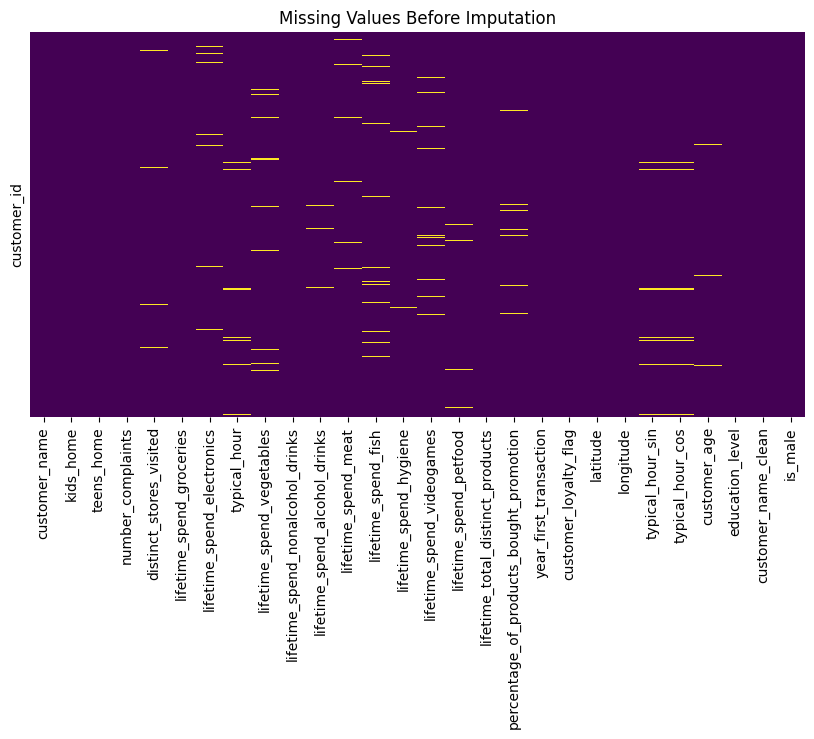

,Missing Count,Percentage (%)
lifetime_spend_fish,991,3.0
lifetime_spend_electronics,661,2.0
typical_hour,661,2.0
lifetime_spend_vegetables,661,2.0
lifetime_spend_meat,661,2.0
lifetime_spend_videogames,661,2.0
lifetime_spend_petfood,661,2.0
typical_hour_sin,661,2.0
typical_hour_cos,661,2.0
distinct_stores_visited,330,1.0


Remaining missing values: 0


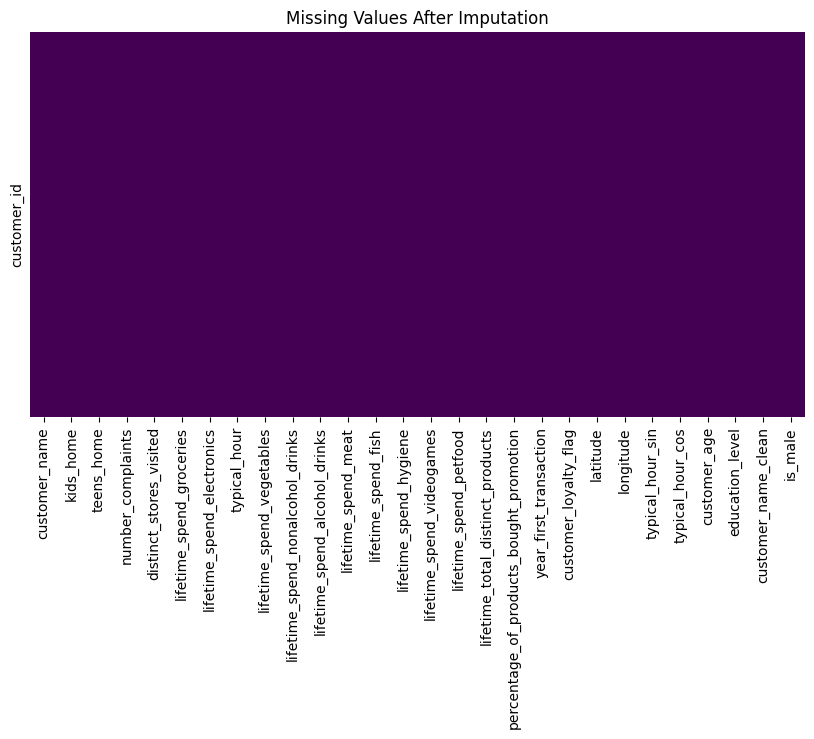

In [43]:
utils.plot_missing_heatmap(ci_clean, "Missing Values Before Imputation")
display(utils.get_missing_report(ci_clean))

ci_clean = utils.apply_knn_imputation(ci_clean, n_neighbors=5)


print("Remaining missing values:", ci_clean.isnull().sum().sum())
utils.plot_missing_heatmap(ci_clean, "Missing Values After Imputation")

In [44]:
to_int = [
    'kids_home', 'teens_home', 'number_complaints', 
    'distinct_stores_visited', 'lifetime_total_distinct_products', 
    'year_first_transaction'
]

for col in to_int:
    if col in ci_clean.columns:
        ci_clean[col] = ci_clean[col].round().astype('Int64')

In [45]:
ci_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  object 
 1   kids_home                                33038 non-null  Int64  
 2   teens_home                               33038 non-null  Int64  
 3   number_complaints                        33038 non-null  Int64  
 4   distinct_stores_visited                  33038 non-null  Int64  
 5   lifetime_spend_groceries                 33038 non-null  float64
 6   lifetime_spend_electronics               33038 non-null  float64
 7   typical_hour                             33038 non-null  float64
 8   lifetime_spend_vegetables                33038 non-null  float64
 9   lifetime_spend_nonalcohol_drinks         33038 non-null  float64
 10  lifetime_spend_alcohol_drinks            33038 non-

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 6.Transformation Feature Engineering</h3>

In [46]:
# A. Create Tenure (Years as a customer)
ci_clean['tenure'] = current_year - ci_clean['year_first_transaction']

# B. Aggregate Spending: Total Lifetime Spend 
spend_cols = [col for col in ci_clean.columns if 'lifetime_spend' in col]
ci_clean['total_spend'] = ci_clean[spend_cols].sum(axis=1)

# C. Household Dynamics: Total Children
ci_clean['total_children'] = ci_clean['kids_home'] +ci_clean['teens_home']

# D. Create a technology spend
ci_clean["lifetime_spend_technology"] = ci_clean["lifetime_spend_electronics"] + ci_clean["lifetime_spend_videogames"]
ci_clean.drop(columns=["lifetime_spend_electronics", "lifetime_spend_videogames"], inplace=True)

In [47]:
ci_clean.columns

Index(['customer_name', 'kids_home', 'teens_home', 'number_complaints',
       'distinct_stores_visited', 'lifetime_spend_groceries', 'typical_hour',
       'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'year_first_transaction',
       'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin',
       'typical_hour_cos', 'customer_age', 'education_level',
       'customer_name_clean', 'is_male', 'tenure', 'total_spend',
       'total_children', 'lifetime_spend_technology'],
      dtype='object')

<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


The final step in our preparation involves aggregating granular data into high-level behavioral metrics. By combining related features, we reduce dimensionality while increasing the signal for our models.

* **Objective:** Synthesize individual data points into overarching "Master Features" that describe customer tenure, spending power, and household dynamics.
* **Logic & Transformations:**
    * **Tenure:** Established by subtracting the `year_first_transaction` from our `current_year` baseline.
    * **Total Spend:** A row-wise summation (`axis=1`) of all columns containing the "lifetime_spend" prefix, providing a single metric for customer lifetime value (CLV).
    * **Household Dynamics:** Combined `kids_home` and `teens_home` into a single `total_children` feature to simplify family-size representation.
    * **Category Focus:** Created a specialized `lifetime_spend_technology` feature by merging electronics and videogame spend, allowing us to isolate tech-heavy consumers.
* **Impact:** These engineered features capture the essence of a customer's relationship with the brand in fewer, more powerful variables, significantly improving the interpretability of future clustering results.

</div>

In [48]:
spend_cols = [col for col in ci_clean.columns if 'lifetime_spend_' in col]

for col in spend_cols:
    pct_col_name = col.replace('lifetime_spend_', 'pct_spend_')
    ci_clean[pct_col_name] = ci_clean[col] / ci_clean['total_spend']

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 7. Outliers Treatment</h3>

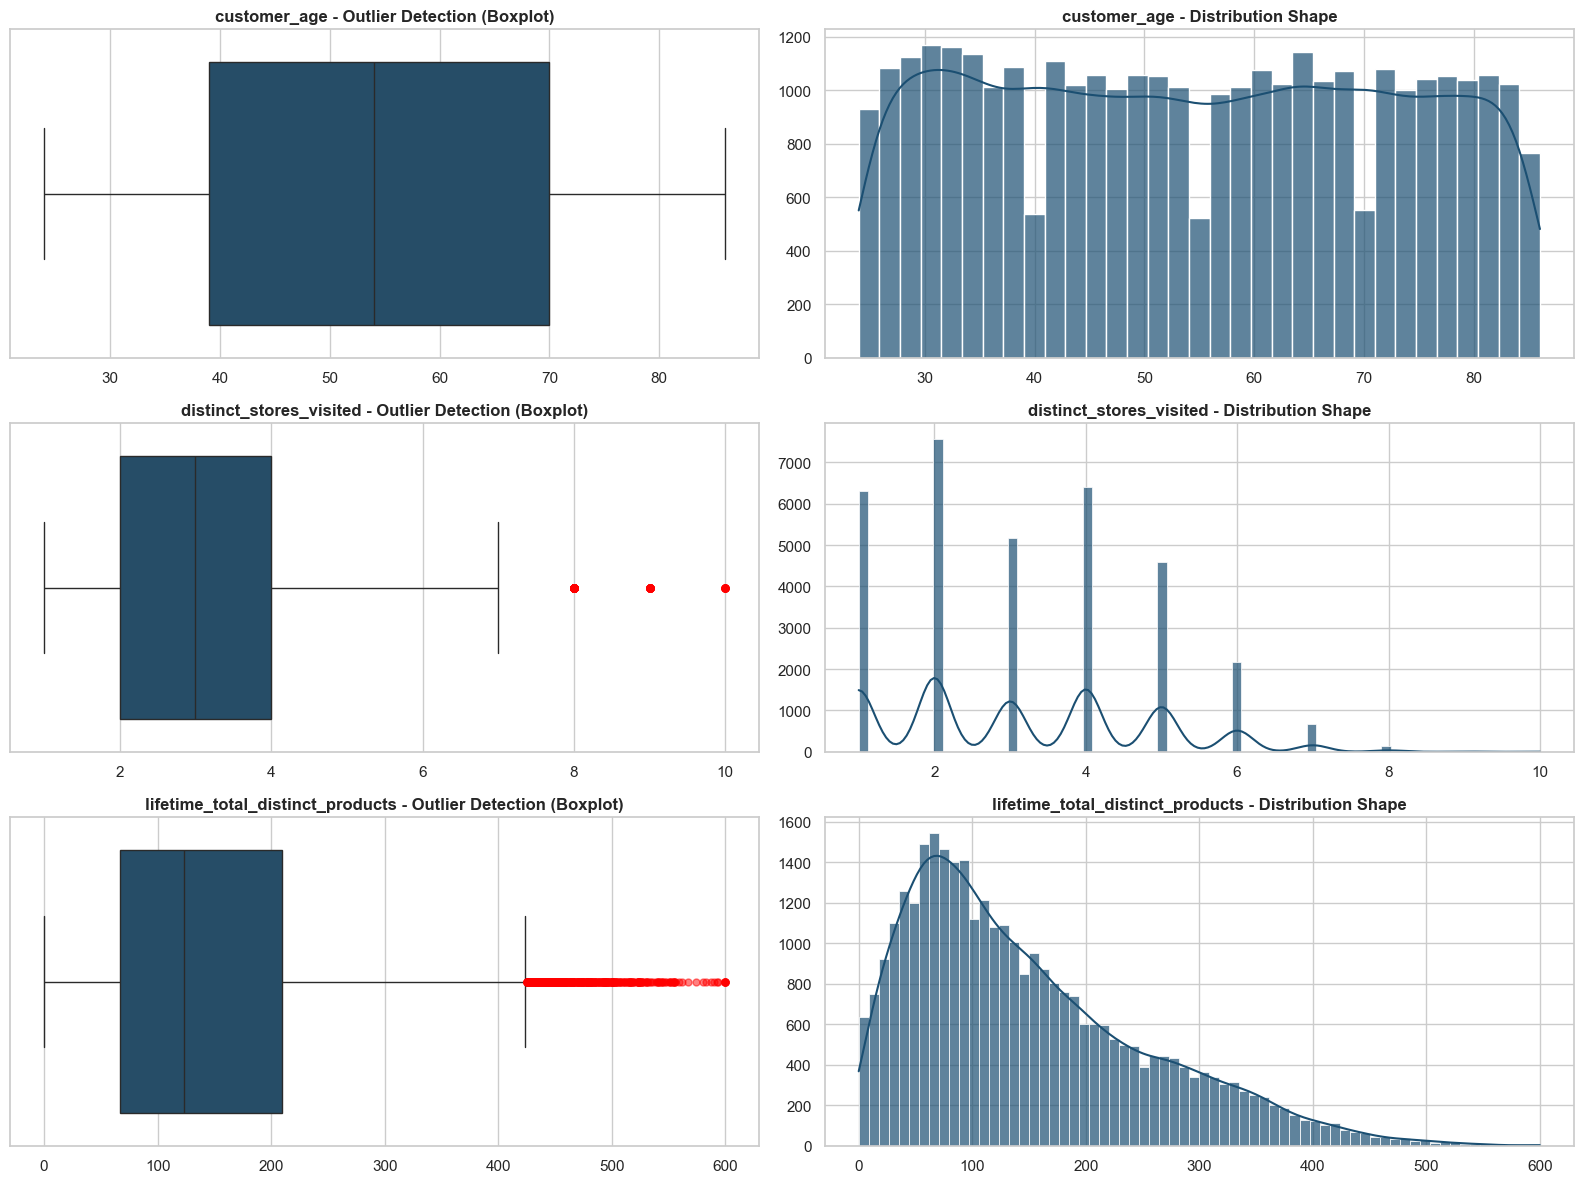

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Definir as colunas que vão ser analisadas (as mesmas que envias para tratamento)
spend_cols = [col for col in ci_clean.columns if 'lifetime_spend' in col]
other_numeric = ['customer_age', 'distinct_stores_visited', 'lifetime_total_distinct_products']
cols_to_visualize = spend_cols + other_numeric

# Configuração visual premium
CUSTOM_BLUE = "#1B4F72"
sns.set_theme(style="whitegrid")

# 2. Criar a matriz de gráficos (Cada coluna terá um Boxplot e um Histograma lado a lado)
n_features = len(cols_to_visualize)
fig, axes = plt.subplots(nrows=n_features, ncols=2, figsize=(16, n_features * 4))

# Garantir que axes seja uma matriz 2D mesmo que haja apenas 1 feature
if n_features == 1:
    axes = np.array([axes])

for i, col in enumerate(cols_to_visualize):
    # --- COLUNA 1: Boxplot (Focado na deteção geométrica de outliers) ---
    sns.boxplot(
        x=ci_clean[col], 
        ax=axes[i, 0], 
        color=CUSTOM_BLUE, 
        flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red", "markersize": 5, "alpha": 0.5}
    )
    axes[i, 0].set_title(f'{col} - Outlier Detection (Boxplot)', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel('')
    
    # --- COLUNA 2: Histograma + KDE (Focado no impacto visual da cauda longa) ---
    sns.histplot(
        data=ci_clean, 
        x=col, 
        kde=True, 
        ax=axes[i, 1], 
        color=CUSTOM_BLUE, 
        alpha=0.7
    )
    axes[i, 1].set_title(f'{col} - Distribution Shape', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('')

# Otimizar o espaçamento entre gráficos para evitar sobreposição de textos
plt.tight_layout()
plt.show()

In [49]:
spend_cols = [col for col in ci_clean.columns if 'lifetime_spend' in col]
other_numeric = ['customer_age', 'distinct_stores_visited', 'lifetime_total_distinct_products']

cols_to_treat = spend_cols + other_numeric

ci_clean = utils.handle_extreme_outliers(ci_clean, cols_to_treat, strategy='cap')

print(f"Extreme outliers treated in {len(cols_to_treat)} columns.")

Extreme outliers treated in 12 columns.



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 8. Multivariate Analysis: Feature Correlation</h3>

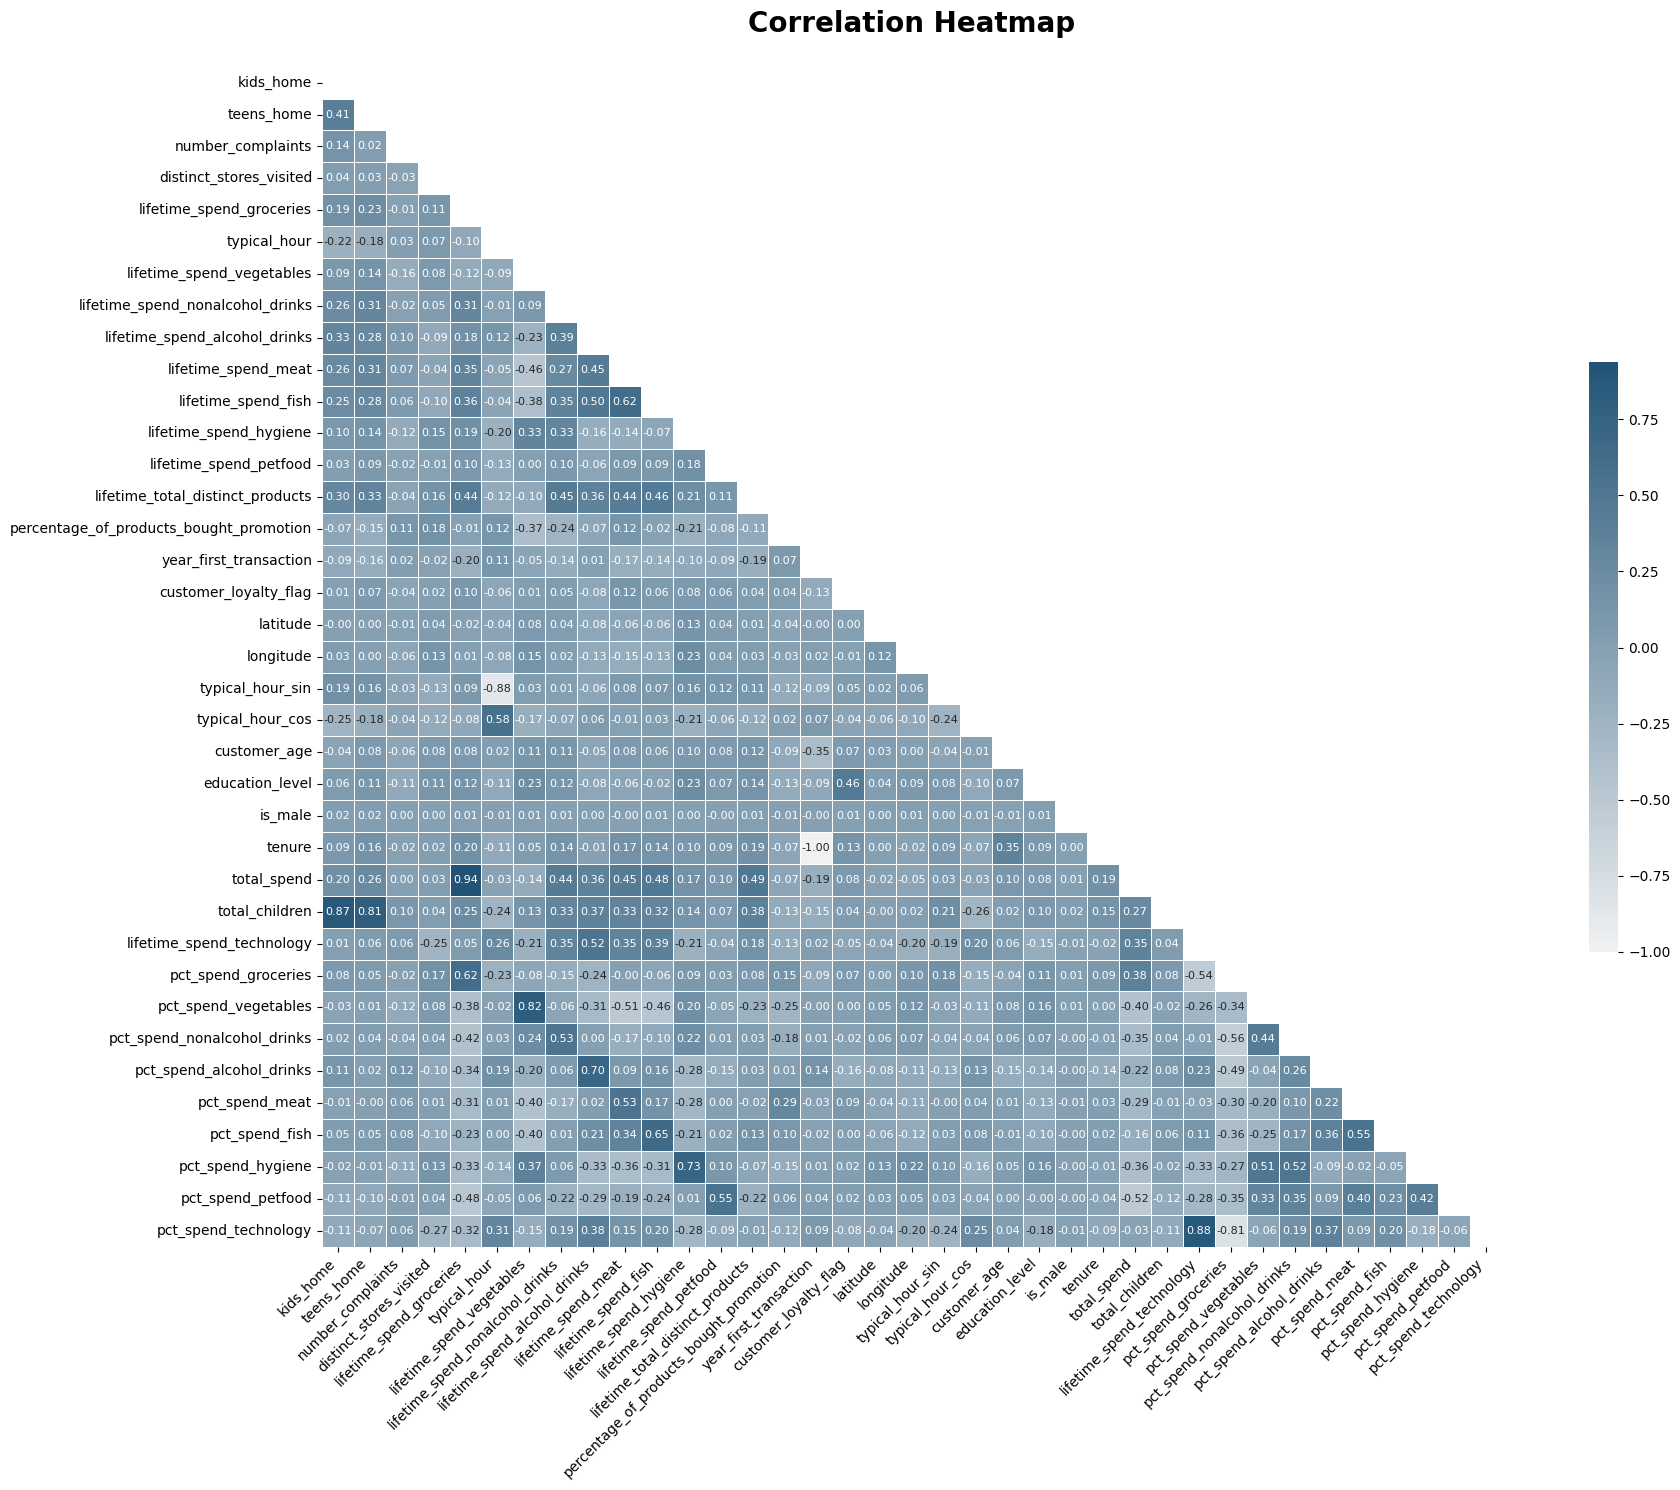

In [50]:
# Select only relevant columns (excluding IDs) for a cleaner map
cols_to_corr = ci_clean.select_dtypes(include=np.number).columns.tolist()
if 'loyalty_card_number' in cols_to_corr: cols_to_corr.remove('loyalty_card_number')

# Call the function from utils
utils.cor_heatmap(ci_clean[cols_to_corr].corr())

In [51]:
high_corrs = utils.get_high_correlations(ci_clean, threshold=0.7)

display(high_corrs)

,Variable 1,Variable 2,Correlation
6,tenure,year_first_transaction,1.000000
2,total_spend,lifetime_spend_groceries,0.939964
3,typical_hour_sin,typical_hour,0.877009
7,pct_spend_technology,lifetime_spend_technology,0.876168
0,total_children,kids_home,0.869777
4,pct_spend_vegetables,lifetime_spend_vegetables,0.818519
1,total_children,teens_home,0.807687
8,pct_spend_technology,pct_spend_groceries,0.806078
5,pct_spend_hygiene,lifetime_spend_hygiene,0.726814


<div style="background-color:#F7FBFF; padding:15px; border-radius:10px;">


With our features engineered and standardized, we perform a multivariate analysis to understand the linear relationships between variables and identify potential multicollinearity.

* **Objective:** Generate a correlation heatmap to visualize how features move in relation to one another and identify highly redundant variables.
* **Key Observations:**
    * **Perfect Correlation (1.0):** `tenure` and `year_first_transaction` are perfectly correlated. This is expected as tenure is a linear transformation of the transaction year.
    * **Strong Drivers:** `total_spend` shows a very high correlation ($0.94$) with `lifetime_spend_groceries`, suggesting groceries are the primary driver of overall volume.
    * **Household Signals:** `total_children` strongly correlates with both `kids_home` ($0.87$) and `teens_home` ($0.81$), validating our aggregation logic.
* **Impact:** Identifying these "High Corrs" is essential for model health. We may consider dropping one of the perfectly correlated features (like `year_first_transaction`) to ensure our clustering algorithm isn't "double-counting" the same underlying signal.

</div>

In [52]:
ci_clean

,customer_name,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,customer_name_clean,is_male,tenure,total_spend,total_children,lifetime_spend_technology,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,Bsc. Crystal Kitchens,1,1,1,3.0,11731.0,12.2,373.0,323.0,177.0,28.0,213.0,552.0,384.0,189.0,0.631599,2020,1,38.794428,-9.215739,-0.037894,-6.313193e-01,56.0,1,Crystal Kitchens,0,6,18590.0,2,4809.00,0.631038,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.020656,0.258687
4,Bsc. Glenda Bauman,1,0,0,2.0,13694.0,10.4,2012.0,533.0,95.0,43.0,15.0,1880.0,665.0,130.0,0.149890,2013,1,38.751711,-9.179611,0.338134,-7.527606e-01,50.0,1,Glenda Bauman,0,13,20233.0,1,1296.00,0.676815,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.032867,0.064054
5,Msc. Antonio Campbell,0,0,0,2.0,12407.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,222.0,81.0,0.069126,2005,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,2,Antonio Campbell,1,21,15549.0,0,101.00,0.797929,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.014277,0.006496
7,John Kelling,0,0,2,1.0,7493.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,184.0,92.0,0.253609,2021,1,38.739548,-9.148679,-1.000000,-1.836970e-16,43.0,0,John Kelling,1,5,14952.0,0,2761.00,0.501137,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.012306,0.184658
8,Arthur Dematteo,0,0,3,1.0,9187.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,441.0,6.0,0.186569,2021,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,0,Arthur Dematteo,1,5,25797.0,0,12099.00,0.356127,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.017095,0.469008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,Joshua Howard,0,0,2,1.0,475.0,18.4,190.0,573.0,994.0,1020.0,1154.0,62.0,366.0,162.0,0.261352,2014,0,38.742306,-9.163971,-0.271744,3.878315e-01,53.0,0,Joshua Howard,1,12,19920.0,0,14364.35,0.023845,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.018373,0.757329
39997,Anthony Hines,1,0,1,1.0,8430.0,21.0,291.0,497.0,1417.0,1323.0,602.0,220.0,227.0,97.0,0.143479,2014,0,38.748505,-9.193445,-0.707107,7.071068e-01,71.0,0,Anthony Hines,1,12,29520.0,1,14364.35,0.285569,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.007690,0.559383
39998,Edna Hasselman,1,1,0,4.0,8029.0,14.0,1600.0,494.0,117.0,307.0,124.4,1719.0,258.0,206.0,0.181917,2012,0,38.776003,-9.137943,-0.500000,-8.660254e-01,81.0,0,Edna Hasselman,0,14,14217.4,2,1569.00,0.564731,0.112538,0.034746,0.008229,0.021593,0.008750,0.120908,0.018147,0.110358


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b> 9.Feature Selection: Removing Irrelevant and Redundant Columns</h3>

<div style="background-color:#F9FCFF; padding:20px; border-radius:10px;">

Before feeding our data into distance-based clustering algorithms (like K-Means), it is crucial to refine our feature set. The presence of redundant columns, textual noise, or variables with perfect multicollinearity can severely distort geometric distance calculations, leading to biased and inaccurate customer segments.

In this section, we structure our column removal strategy into three main categories:
* **Identifiers and Raw Text:** Variables that contain no behavioral signal.
* **Perfect Multicollinearity:** Variables that share an exact mathematical relationship with features we already kept.
* **Structural Redundancy:** Simplifying columns that have already been aggregated into master features (e.g., household dynamics and absolute spending).

</div>

In [54]:
ci_clean.drop(columns=['typical_hour'], inplace=True)

In [55]:
columns_to_drop = [
    'customer_name',       
    'customer_name_clean', 
    'year_first_transaction',
    'latitude', 'longitude',
    'kids_home', 'teens_home'
]

columns_to_drop.extend(spend_cols)


ci_clean.drop(columns=columns_to_drop, inplace=True, errors='ignore')


print(ci_clean.columns.tolist())

['number_complaints', 'distinct_stores_visited', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'customer_loyalty_flag', 'typical_hour_sin', 'typical_hour_cos', 'customer_age', 'education_level', 'is_male', 'tenure', 'total_spend', 'total_children', 'pct_spend_groceries', 'pct_spend_vegetables', 'pct_spend_nonalcohol_drinks', 'pct_spend_alcohol_drinks', 'pct_spend_meat', 'pct_spend_fish', 'pct_spend_hygiene', 'pct_spend_petfood', 'pct_spend_technology']


In [57]:
# 1. Definir o caminho de destino (baseado no caminho de leitura original)
output_path = "/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/datasets/customer_info_clean.csv"

# 2. Exportar o DataFrame para CSV garantindo que o ID do cliente é mantido como índice
ci_clean.to_csv(output_path, index=True)

print(f"✅ O DataFrame foi exportado com sucesso para:\n{output_path}")

✅ O DataFrame foi exportado com sucesso para:
/Users/franciscateixeira/Documents/ML/CostumerSegP_MLII/datasets/customer_info_clean.csv
